# Conversation dynamics in podcasts: An analysis of interruptions, calls to action and sentiment across genres
This project aims to analyze conversational dynamics in podcasts using the SPORC dataset, which provides annotated podcast transcriptions with speaker and dialogue turn information. In the project, we focus on three key elements of conversational dynamics; interruptions, calls to action, and sentiment. These will be the lenses for understanding how podcast conversations differ across genres. By analyzing the existence and nature of interruptions, the use of persuasive and action oriented language toward the listeners, along with the sentiments and emotional tone, we wish to compare and characterize how conversational patterns vary between genres of podcasts. The analysis aims at sheding light on how podcasts communicate and engage audiences differently depending on their genre.

This notebook consists of an initial data exploration pipeline, and then methodological considerations for each of the parts of the analysis, which will be conducted in the P3 milestone part of this project.

## Data exploration
In this part of the notebook we have worked with loading and understanding the data to ensure the feasibility of our ideas on the actual dataset. We have calculated the descriptive statistics of the dataset at both podcast, episode and turn levels. Furthermore, we have plotted the content of the dataset and done initial interaction with the data to understand the available columns in each part of the dataset. We have used a modified version of the `sporc` library to interact with the data, and familiarized ourselves with the available functionality in here. 

### Import dependencies

In [2]:
from helpers.sporc import (
    SPORCDataset,
    get_all_categories,
    get_main_categories,
    get_main_category,
    get_subcategories_list,
    is_main_category,
    is_subcategory,
    is_valid_category,
)
from pprint import pprint
import matplotlib.pyplot as plt
from typing import Optional
import pandas as pd
import re

### Load data

I have appropriated the `sporc` library to our needs. You can load the full data from hugging face (if logged in) using 
        
    sporc = SPORCDataset()

It is also possible to use `streaming` so you wont load any data before iterating over it
    
    sporc = SPORCDataset(streaming=True)

If you have the compressed files (.gz) locally they can be read as

    sporc = SPORCDataset(local_data_dir="data")

However, since the full data is needlessly large for our purposes we will only be using the provided sample, which can be loaded as follows:

In [3]:
sporc = SPORCDataset(
    local_data_dir="data",
    load_samples_only=True,
    load_turns_eagerly=True,
    show_progress=False,
)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 6.39 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...
INFO:helpers.sporc.dataset:✓ Separation completed in 0.11 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:he

In [4]:
stats = sporc.get_dataset_statistics()

print(f"Total podcasts: {stats['total_podcasts']}")
print(f"Total episodes: {stats['total_episodes']}")
print(f"Total duration: {stats['total_duration_hours']:.1f} hours")
print(f"Average episode length: {stats['avg_episode_duration_minutes']:.1f} minutes")

print("\nTop categories:")
for category, count in sorted(stats['category_distribution'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")
    
print("\nTop Languages:")
for category, count in sorted(stats['language_distribution'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")
    
print("\nTop Episode Types:")
for category, count in sorted(stats['episode_types'].items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {category}: {count} episodes")

Total podcasts: 1826
Total episodes: 10000
Total duration: 5760.4 hours
Average episode length: 34.6 minutes

Top categories:
  : 73612 episodes
  religion: 2109 episodes
  spirituality: 2106 episodes
  society: 1609 episodes
  culture: 1609 episodes

Top Languages:
  en: 7926 episodes
  en-us: 1261 episodes
  en-US: 482 episodes
  en-gb: 163 episodes
  en-au: 39 episodes

Top Episode Types:
  long_form: 4838 episodes
  short_form: 2059 episodes
  solo: 1836 episodes
  interview: 1613 episodes
  panel: 684 episodes


In [5]:
# Demonstrate category utility functions
print("Category Utility Functions:")

# Get all categories
all_categories = get_all_categories()
main_categories = get_main_categories()
subcategories = get_subcategories_list()

print(f"   Total categories: {len(all_categories)}")
print(f"   Main categories: {len(main_categories)}")
print(f"   Subcategories: {len(subcategories)}")

# Show some main categories
print(f"   Sample main categories: {main_categories[:5]}")
print(f"   Sample subcategories: {subcategories[:5]}")
print()

# Demonstrate category validation
print("Category Validation:")
test_categories = ["Education", "Astronomy", "Invalid Category", "Language Learning"]

for category in test_categories:
    is_valid = is_valid_category(category)
    is_main = is_main_category(category)
    is_sub = is_subcategory(category)

    print(f"   '{category}':")
    print(f"     Valid: {is_valid}")
    print(f"     Main category: {is_main}")
    print(f"     Subcategory: {is_sub}")

print()

Category Utility Functions:
   Total categories: 114
   Main categories: 19
   Subcategories: 95
   Sample main categories: ['Arts', 'Business', 'Comedy', 'Education', 'Fiction']
   Sample subcategories: ['After Shows', 'Alternative Health', 'Animation & Manga', 'Astronomy', 'Automotive']

Category Validation:
   'Education':
     Valid: True
     Main category: True
     Subcategory: False
   'Astronomy':
     Valid: True
     Main category: False
     Subcategory: True
   'Invalid Category':
     Valid: False
     Main category: False
     Subcategory: False
   'Language Learning':
     Valid: True
     Main category: False
     Subcategory: True



In [6]:
# Demonstrate category hierarchy & distribution 
# Note that an episode can have multiple categories
sporc.plot_category_sunburst() 

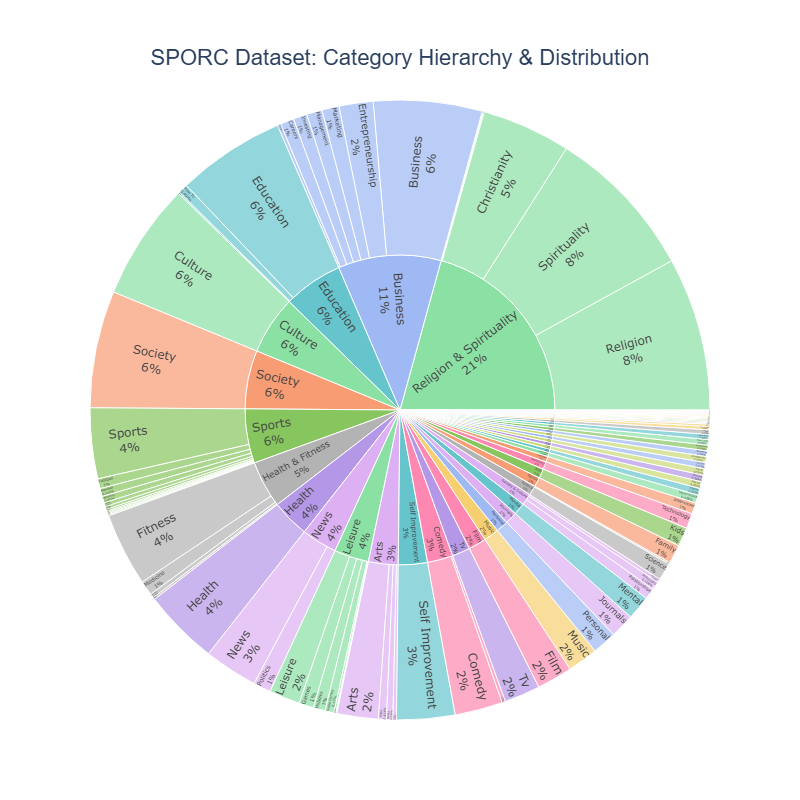

In [7]:
# Note: This plot is interactive and not visible in the rendered notebook in Github. Instead see this static image:
from IPython.display import Image
Image(filename='figures/sunburst.png') 

### Interacting with the dataset

Through `sporc` the data can be accessed through `Podcast` and `Episode` objects

In [8]:
# Accessing podcast and episode data
podcasts = sporc.get_all_podcasts() # List of Podcast objects
episodes = sporc.get_all_episodes() # List of Episode objects

print(f"Total podcasts: {len(podcasts)}")
print("Example podcast:", podcasts[0])

print(f"\nTotal episodes: {len(episodes)}")  
print("Example episode:", episodes[0])

Total podcasts: 1826
Example podcast: Podcast('SingOut SpeakOut', 5 episodes, 0.7h)

Total episodes: 10000
Example episode: Episode('Best of SingOut SpeakOut No.3', 13.4min, 1 speakers)


In [9]:
for i, podcast in enumerate(podcasts[:5]):
    print(f"[{i+1}] {podcast.title} ({len(podcast.episodes)} episodes)")

[1] SingOut SpeakOut (5 episodes)
[2] Brazen Education (2 episodes)
[3] California Community Colleges Podcast (1 episodes)
[4] Puck Bunnies (1 episodes)
[5] Anxiety 2 Confidence podcast (6 episodes)


#### Working with Podcasts

In [10]:
# searching for a podcast
podcast = sporc.search_podcast("singout speakout")

print(f"Title: {podcast.title}")
pprint(f"Description: {podcast.description}")
print(f"Number of episodes: {podcast.num_episodes}")
print(f"Total duration: {podcast.total_duration_hours:.1f} hours")
print(f"Hosts: {podcast.host_names}")
print(f"Categories: {podcast.categories}")

Title: SingOut SpeakOut
('Description: Award winning Australian singer-songwriter Simon Shapiro '
 'delivers his songs, writing and philosophy in a unique combination of idea '
 'sharing, including conversation, live performance and recorded music.')
Number of episodes: 5
Total duration: 0.7 hours
Hosts: ['Simon Shapiro']
Categories: ['', 'culture', 'education', 'music', 'philosophy', 'self improvement', 'society']


In [11]:
pprint(podcast.get_episode_statistics())

{'avg_episode_duration_minutes': 8.546666666666667,
 'category_distribution': {'': 20,
                           'culture': 5,
                           'education': 5,
                           'music': 5,
                           'philosophy': 5,
                           'self improvement': 5,
                           'society': 5},
 'date_range': {'earliest': '2020-05-17T12:00:00',
                'latest': '2020-06-20T23:00:00'},
 'episode_types': {'interview': 1,
                   'long_form': 0,
                   'panel': 0,
                   'short_form': 4,
                   'solo': 4},
 'guest_names': ['Lee Walker'],
 'host_names': ['Simon Shapiro'],
 'max_episode_duration_minutes': 13.383333333333333,
 'median_episode_duration_minutes': 7.933333333333334,
 'min_episode_duration_minutes': 6.0,
 'num_episodes': 5,
 'speaker_distribution': {1: 1, 3: 3, 4: 1},
 'total_duration_hours': 0.7122222222222222}


In [12]:
# Iterate through episodes
for episode in podcast.episodes:
    print(f"Episode: {episode.title}")
    print(f"Duration: {episode.duration_minutes:.1f} minutes")
    print(f"Date: {episode.episode_date}")
    print("---")

Episode: Quarterlife Crisis
Duration: 8.5 minutes
Date: 2020-05-17 12:00:00
---
Episode: Saturn Return
Duration: 7.9 minutes
Date: 2020-05-24 11:00:00
---
Episode: Today Is Yesterday
Duration: 6.9 minutes
Date: 2020-05-31 13:00:00
---
Episode: It's All Gone
Duration: 6.0 minutes
Date: 2020-06-14 14:00:00
---
Episode: Best of SingOut SpeakOut No.3
Duration: 13.4 minutes
Date: 2020-06-20 23:00:00
---


#### Working with Episodes

In [13]:
episode = podcast.episodes[0]

print(f"Title: {episode.title}")
pprint(f"Description: {episode.description}")
print(f"Duration: {episode.duration_minutes:.1f} minutes")
print(f"Hosts: {episode.host_names}")
print(f"Guests: {episode.guest_names}")
print(f"Categories: {episode.categories}")
print(f"Main speakers: {episode.num_main_speakers}")
pprint(f"Transcript: {episode.transcript[:300]}...")


Title: Quarterlife Crisis
('Description: <p>Big news week. The band Simon lived in the USA with, KisTone '
 'has released their debut album after 12 years of red tape. Simon runs '
 'through a brief history of the band and then introduces track 1, Quarterlife '
 'Crisis.</p>')
Duration: 8.5 minutes
Hosts: ['Simon Shapiro']
Guests: ['Lee Walker']
Categories: ['music', 'society', 'culture', 'philosophy', 'education', 'self improvement', '', '', '', '']
Main speakers: 3
("Transcript: I'm Simon Shapiro and this is Sing Out Speak Out. Here I give "
 "you the philosophies, ideas and songs I've been working on for many years "
 "but until now I've shared just too few of because I've been afraid of you "
 "and worse I've been afraid of me. My will to connect with you and share the "
 'best of me has...')


In [14]:
# Episode type flags
print(f"Is solo episode: {episode.is_solo}")
print(f"Is interview: {episode.is_interview}")
print(f"Is panel discussion: {episode.is_panel}")
print(f"Is long-form: {episode.is_long_form}")
print(f"Has guests: {episode.has_guests}")

Is solo episode: False
Is interview: True
Is panel discussion: False
Is long-form: False
Has guests: True


In [15]:
pprint(episode.get_turn_statistics())

{'avg_turn_duration': 33.97866666666667,
 'avg_words_per_turn': 47.0,
 'role_distribution': {'NO_INFERRED_ROLE': 12, 'host': 3},
 'speaker_distribution': {'SPEAKER_00': 6,
                          'SPEAKER_01': 5,
                          'SPEAKER_02': 4,
                          'SPEAKER_03': 4},
 'total_turns': 15,
 'total_words': 705}


In [16]:
# Filter by runtime
long_episodes = sporc.search_episodes(min_duration=1800) # episodes longer than 30 min
short_episodes = sporc.search_episodes(max_duration=600) # episodes shorter than 10 min

# Filter by speaker participation
solo_episodes = sporc.search_episodes(max_speakers=1)
group_episodes = sporc.search_episodes(min_speakers=3)

# Filter by host identity
episodes_by_simon = sporc.search_episodes(host_name="Simon Shapiro")

# Filter by thematic category
sport_episodes = sporc.search_episodes(category="sports")
music_episodes = sporc.search_episodes(category="music")

# Combine filters for more specific search
specefic_episodes = sporc.search_episodes(
    category="education", 
    min_speakers=2,
    min_duration=1800  
)

# Sampling examples
# Randomly sample 100 sports-related episodes
sampled_sport_episodes = sporc.search_episodes(
    category="sports",
    sampling_mode="random",
    max_episodes=100
)
# Select the first 50 long-form episodes
first_long_episodes = sporc.search_episodes(
    min_duration=1800,
    sampling_mode="first",
    max_episodes=50
)

In [17]:
episodes_by_simon # List of Episode objects

[Episode(title='Best of SingOut SpeakOut No.3', duration_seconds=803.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='It's All Gone', duration_seconds=360.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Today Is Yesterday', duration_seconds=416.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Saturn Return', duration_seconds=476.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=0),
 Episode(title='Quarterlife Crisis', duration_seconds=509.0, podcast_title='SingOut SpeakOut', num_hosts=1, num_guests=1)]

#### Working with Conversation Turns

In [18]:
turns = episode.get_all_turns()

print(f"Total turns: {len(turns)}", end="\n\n")

for turn in turns[:5]:
    print(f"Speaker: {turn.primary_speaker}")
    print(f"Duration: {turn.duration:.1f} seconds")
    print(f"Words: {turn.word_count}")
    print(f"Text: {turn.text[:100]}...")
    print("---")

Total turns: 15

Speaker: SPEAKER_00
Duration: 37.2 seconds
Words: 77
Text:  I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs...
---
Speaker: SPEAKER_00
Duration: 0.3 seconds
Words: 1
Text:  Hi...
---
Speaker: SPEAKER_01
Duration: 4.5 seconds
Words: 4
Text:  everyone, welcome to another...
---
Speaker: SPEAKER_01
Duration: 1.6 seconds
Words: 1
Text:  episode...
---
Speaker: SPEAKER_00
Duration: 179.6 seconds
Words: 595
Text:  of Sing Out Speak Out. Exciting news today, we have just released, I want to say we, I mean a coupl...
---


In [19]:
# Calculate basic turn statistics
durations = [turn.duration for turn in turns]
word_counts = [turn.word_count for turn in turns]

print(f"Average turn duration: {sum(durations) / len(durations):.1f} seconds")
print(f"Average words per turn: {sum(word_counts) / len(word_counts):.1f}")
print(f"Longest turn: {max(durations):.1f} seconds")
print(f"Shortest turn: {min(durations):.1f} seconds")
print(f"Total conversation time: {sum(durations) / 60:.1f} minutes")

Average turn duration: 34.0 seconds
Average words per turn: 47.0
Longest turn: 179.6 seconds
Shortest turn: 0.3 seconds
Total conversation time: 8.5 minutes


In [20]:
# Get turns from first 5 minutes
early_turns = episode.get_turns_by_time_range(0, 300)

# Get turns from last 10 minutes
late_turns = episode.get_turns_by_time_range(
    episode.duration_seconds - 600,
    episode.duration_seconds
)

# Get all turns by a specific speaker
speaker_turns = episode.get_turns_by_speaker("SPEAKER_00")

# Get all turns by host
host_turns = episode.get_host_turns()

# Get all turns by guests
guest_turns = episode.get_guest_turns()

# Get turns with at least 50 words
long_turns = episode.get_turns_by_min_length(50)

# <font color="red"> DO WE KEEP THIS HERE?</font>


> ### Problems with data
> The dataset is very detailed and straightforward to work with using the sporc library, but there are still some issues with the data to be ware of. We have found the following issues, which we will adress and think about throughout the analysis to be performed in the project:
>- Inaccuracies in the labeled speaker turns
>    - It is observed that one actual speaker turn is sometimes divided into smaller turns following each other by the same speaker, without the turn actually being broken
>    - It is also observed that podcasts without guests and only one host sometimes have turns labeled with speaker 0 and speaker 1 despite there only being one speaker
>    - Some turns metadata is also sometimes wrong, e.g. inaccurate turn duration
>    - Speaker labels are inferred using NER and heuristics, so they may be misassigned
>- Some episodes don't have any turns
>    - Despite a transscript of an episode existing there may be no turns associated with that episode, which makes some sorts of analysis impossible
>
>There might be more issues, which we have not uncovered in this initial inspection of data, but it may uncover itself during the analysis performed until P3 milestone. All of the above issues will be thought out carefully in the relation to the analysis, and will be handled and reported accordingly to be transparant about possible effects e.g. for bad turn labeling, metadata and splitting for interruption analysis, where this information is key for detection of interruptions through overlapping turns by different speakers through e.g. start and end times.
___

## Creating a usable episode set

Among the data we can load reliably, only a portion includes the `turns` object, meaning those without it have no temporal dimension. Consequently, we cannot apply our interruption analysis, which relies on this dimension. This is not entirely bad, since a smaller set works as a proof of concept for our analysis while also limiting the time needed to run costly LLMs.

Additionally, we will designate a main category to use in downstream analysis. To do this, we define a few helper functions to:
- Normalize categories to main Apple categories.
- Filter out episodes without turns, transcripts, or categories.


In [21]:
main_categories = set(main_categories)

def resolve_main_category(category):
    "Map to a known main category; return None when unrecognized."
    if not category:
        return None
    normalized = category.strip().title()
    if not normalized:
        return None
    if normalized in main_categories:
        return normalized
    mapped = get_main_category(normalized)
    if mapped in main_categories:
        return mapped
    return None


def pick_primary_category(categories):
    "Prefer recognized main categories; otherwise fall back to the first unknown label."
    main_categories_ = []
    seen = set()
    first_unrecognized: Optional[str] = None
    for category in categories:
        resolved = resolve_main_category(category)
        if resolved and resolved not in seen:
            main_categories_.append(resolved)
            seen.add(resolved)
            continue
        if first_unrecognized is None:
            normalized = (category or "").strip().title()
            if normalized:
                first_unrecognized = normalized
    if not main_categories_ and first_unrecognized:
        main_categories_.append(first_unrecognized)
    primary = main_categories_[0] if main_categories_ else None
    return primary, main_categories_

def episode_to_record(episode):
    "Convert an Episode to a flat record if it meets our usability criteria."
    if not episode.has_turns:
        return None

    primary_main, all_main_categories = pick_primary_category(episode.categories)
    if not primary_main:
        return None

    transcript_length = len((episode.transcript or "").strip())
    if transcript_length == 0:
        return None

    return {
        "podcast_title": episode.podcast_title,
        "episode_title": episode.title,
        "duration_minutes": episode.duration_minutes,
        "turn_count": episode.turn_count,
        "main_category": primary_main,
        "all_main_categories": all_main_categories,
        "all_categories": episode.categories,
        "transcript_chars": transcript_length,
        "has_guests": episode.has_guests,
        "num_guests": episode.num_guests,
        "num_hosts": episode.num_hosts,
        "is_interview": episode.is_interview,
        "is_panel": episode.is_panel,
        "is_solo": episode.is_solo,
        "overlap_prop_duration": episode.overlap_prop_duration,
        "overlap_prop_turn_count": episode.overlap_prop_turn_count,
        "mp3_url": episode.mp3_url, # We will use this as the key
    }

### Building the pool of usable episodes
We filter out items without categories, transcripts, or turns.

In [22]:
records = []

for episode in episodes:
    record = episode_to_record(episode)
    if record:
        records.append(record)

usable_df = pd.DataFrame(records)
print(f"Usable episodes (turns > 0, transcript, main category): {len(usable_df)}")
print(f"Share with exactly one turn: {(usable_df['turn_count']==1).mean():.1%}")
usable_df.head()

Usable episodes (turns > 0, transcript, main category): 1033
Share with exactly one turn: 15.1%


,podcast_title,episode_title,duration_minutes,turn_count,main_category,all_main_categories,all_categories,transcript_chars,has_guests,num_guests,num_hosts,is_interview,is_panel,is_solo,overlap_prop_duration,overlap_prop_turn_count,mp3_url
0,SingOut SpeakOut,Best of SingOut SpeakOut No.3,13.383333,1,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",638,False,0,1,False,False,True,0.000000,0.000000,https://www.buzzsprout.com/783020/4252475-best...
1,SingOut SpeakOut,It's All Gone,6.000000,3,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",660,False,0,1,False,False,True,0.000000,0.000000,https://www.buzzsprout.com/783020/4165286-it-s...
2,SingOut SpeakOut,Today Is Yesterday,6.933333,13,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3972,False,0,1,False,False,True,0.001847,0.153846,https://www.buzzsprout.com/783020/3983942-toda...
3,SingOut SpeakOut,Saturn Return,7.933333,12,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3120,False,0,1,False,False,True,0.005649,0.166667,https://www.buzzsprout.com/783020/3892169-satu...
4,SingOut SpeakOut,Quarterlife Crisis,8.483333,15,Music,"[Music, Society & Culture, Education]","[music, society, culture, philosophy, educatio...",3535,True,1,1,True,False,False,0.035983,0.266667,https://www.buzzsprout.com/783020/3791501-quar...


In [23]:
category_counts = usable_df["main_category"].value_counts().sort_values(ascending=False)
print("Category distribution in usable pool:")
display(category_counts)

Category distribution in usable pool:


main_category
Business                   165
Religion & Spirituality    163
Education                  145
Society & Culture          119
Health & Fitness           102
Sports                      69
Music                       48
Arts                        47
Comedy                      46
Leisure                     43
TV & Film                   30
News                        23
Technology                   9
Fiction                      6
True Crime                   5
Kids & Family                5
Science                      4
Government                   3
History                      1
Name: count, dtype: int64

Because episode objects are not directly serializable into a DataFrame, we store them separately while keeping them accessible for downstream interaction and analysis.

In [24]:
episode_lookup = {ep.mp3_url: ep for ep in episodes}
episodes = (usable_df['mp3_url'].map(episode_lookup)).to_list()

Finally, we save this small dataset

In [25]:
usable_df.to_parquet("data/episodes.parquet", index=False)
episodes_df = pd.read_parquet("data/episodes.parquet")

### Building the Turn-Level Dataset

Since our analysis requires operating at the level of individual turns rather than whole episodes, we construct a turn-level dataset. For each episode, we iterate through its sequence of turns, clean the text, extract relevant metadata (such as speaker, timing, and duration), and annotate properties like whether the turn was removed during cleaning or flagged as short.

The result is a flat dataframe where each row corresponds to a single turn, enabling turn-level statistics, filtering, and downstream modeling.

Before constructing this dataset, we first define a text-cleanup function that standardizes and filters turn content. This function uses a set of regular expressions to remove non-linguistic artifacts such as: `[music]` cues, stray brackets, and leading or trailing punctuation, and normalizes whitespaces. This preprocessing step ensures that the turn-level dataset contains clean, structured text suitable for both descriptive statistics and more advanced modeling.

In [53]:
MUSIC_PATTERN = re.compile( 
    r""" # Matches various forms of 'music' cues
        (\[\s*music\s*\]|\(\s*music\s*\))   
        |(\[\s*music)                       
        |(music\s*\])                       
        |^\s*music\s*$                      
    """,
    re.IGNORECASE | re.VERBOSE,
)

# Remove leftover brackets, quotes, stray punctuation clusters
#BRACKET_JUNK = re.compile(r'[\[\]\(\)]+')

def clean_turn_text(text):
    """Clean a turn's text by removing music cues, bracket noise,  
    leading punctuation, and normalizing whitespace.
    """
    if not text:
        return None

    cleaned = MUSIC_PATTERN.sub(" ", text)
    #cleaned = BRACKET_JUNK.sub(" ", cleaned)

    cleaned = cleaned.strip()
    cleaned = re.sub(r'^[\W_]+', '', cleaned) # remove leading non-alphanumerics
    cleaned = re.sub(r'[\W_]+$', '', cleaned) # remove trailing non-alphanumerics

    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    if not cleaned:
        return None

    return cleaned

In [54]:
turn_rows = []
for i, row in episodes_df.iterrows():
    ep = episodes[i]
    for j, turn in enumerate(ep.get_all_turns()):
        cleaned = clean_turn_text(turn.text)
        turn_rows.append({
            'episode_title': row['episode_title'],
            'turn_index': j,
            'speaker': ';'.join(turn.speaker) if isinstance(turn.speaker, list) else turn.speaker,
            'start_time': turn.start_time,
            'end_time': turn.end_time,
            'duration': turn.duration,
            'raw_text': turn.text,
            'clean_text': cleaned,
            'is_removed': cleaned is None,
            'num_words': len(cleaned.split()) if cleaned else 0,
            'mp3_url': row['mp3_url'],            
        })
turns_df = pd.DataFrame(turn_rows)
print(f'Turn rows: {len(turns_df):,} | removed in cleaning: {turns_df['is_removed'].sum():,}')
turns_df.head()

Turn rows: 199,491 | removed in cleaning: 11,028


,episode_title,turn_index,speaker,start_time,end_time,duration,raw_text,clean_text,is_removed,num_words,mp3_url
0,Best of SingOut SpeakOut No.3,0,SPEAKER_00,0.00,60.00,60.00,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,124,https://www.buzzsprout.com/783020/4252475-best...
1,It's All Gone,0,SPEAKER_00,0.00,78.16,78.16,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,172,https://www.buzzsprout.com/783020/4165286-it-s...
2,It's All Gone,1,SPEAKER_02,78.16,115.31,37.15,Music] [Music] [Music] [Music] [Music] [,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...
3,It's All Gone,2,SPEAKER_01,115.31,360.16,244.85,Music] [Music] [Music] [Music] [Music] [Music]...,None,True,0,https://www.buzzsprout.com/783020/4165286-it-s...
4,Today Is Yesterday,0,SPEAKER_05,0.00,36.99,36.99,I'm Simon Shapiro and this is Sing Out Speak ...,I'm Simon Shapiro and this is Sing Out Speak O...,False,77,https://www.buzzsprout.com/783020/3983942-toda...


**Note:** A large share of turns are very short (often fewer than a few words), indicating that the transcript quality may be limited or that many turns contain minimal linguistic content. This is important to keep in mind when interpreting downstream analyses.


In [55]:
thresholds = [2, 3, 5, 8, 10, 20, 50, 100]

# Keep only valid (non-removed) turns
valid = turns_df[~turns_df['is_removed']]['num_words']

total = len(valid)

print("Distribution of turn lengths (excluding removed turns):")
for threshold in thresholds:
    count = (valid < threshold).sum()
    pct = (count / total) * 100
    print(f"  - Turns with < {threshold:3} words: {count:7,} ({pct:5.1f}%)")

Distribution of turn lengths (excluding removed turns):
  - Turns with <   2 words:  55,287 ( 29.3%)
  - Turns with <   3 words:  74,789 ( 39.7%)
  - Turns with <   5 words:  98,017 ( 52.0%)
  - Turns with <   8 words: 113,392 ( 60.2%)
  - Turns with <  10 words: 120,089 ( 63.7%)
  - Turns with <  20 words: 140,097 ( 74.3%)
  - Turns with <  50 words: 164,376 ( 87.2%)
  - Turns with < 100 words: 177,047 ( 93.9%)


# <font color="red"> OBS! prettify plot?/remove</font>

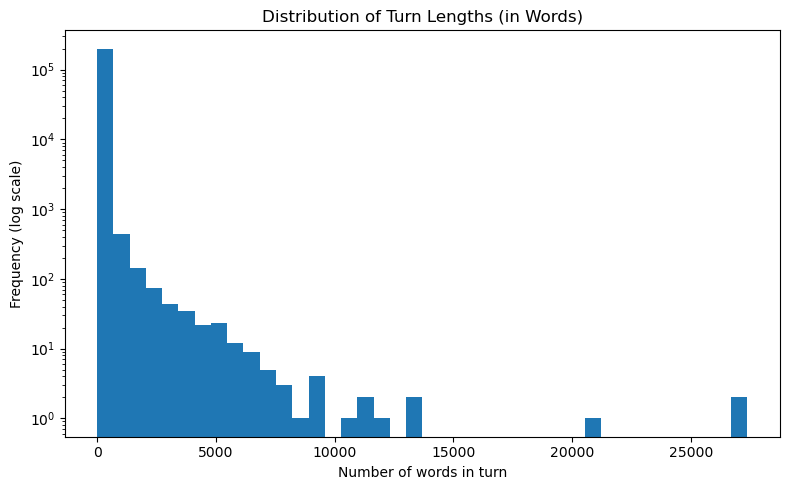

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(turns_df['num_words'], bins=40)
plt.yscale('log')
plt.xlabel("Number of words in turn")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Turn Lengths (in Words)")
plt.tight_layout()
plt.show()

Finally, we save this turn-level dataset for future use.


In [57]:
turns_df.to_parquet("data/turns.parquet", index=False)
turns_df = pd.read_parquet("data/turns.parquet")

## Analysis & Data Enriching

### Sentiment Analysis
1. Use existing lexicons of sentiments e.g. VADER, nrc, AFINN, Bing (combination of emotions and categorical/numeric scores)
2. HuggingFace fine-tuned transformer 
3. Other approaches?

Try to run the different methods on the data and do proxy evaluations with no ground truth by:
- Comparing inter-method agreement on sentiments and polarity
- Do a sanity check of a sample
- Pull samples with highest and lowest confidence and check for "traps" giving wrong labels or "shortcuts" to the right label
- Check which words are often found togehter with negations like not, cant etc., to see if that could influence the results + do an actual flip test by testing statements and the same statement prefixed with not to compare sentiments and scores (robustness)

When choosing a method also run an evaluation on a known emotion/sentiment benchmark to make sure performance there is also reasonable as an additonal sanity check.

When landing on an approach the analysis should consist of sentiment analysis and descriptive overviews and comparisons as well as time series overview of sentiment over an episode length. Both should be supported by nice visualizations to tell the story of the use of emotions and polarity in the podcasts across each genre. Inspired to some degree by this report: https://www.kaggle.com/code/josephnehrenz/nlp-sentiment-analysis-of-joe-rogan-experience/report but with added elements. 

______

### Call-to-Action Detection Pipeline

_____

### Interruptions analysis

Diving into the analysis of interruptions, might unravel hidden patterns and relationships between the different genres and conversational dynamics, which could be interesting to explore. The analysis will be carried out in the following steps:

#### 1. Detection Pipeline:
- Use the explicit appoach of doing speech overlap detection based on time-aligned speaker diarization data to detect interruptions
- Apply acoustic feature analysis (e.g., changes in energy, pitch, or pause duration) to refine detection and distinguish genuine interruptions from non-interruptions
- Look into alternative machine-learning based approaches for more flexible interruption detection

#### 2. Feature extraction:
- Extract features such as interruption duration, speaker roles (initiator vs. target), position within a turn, and other relevant information
- Compute aggregate metrics like interruption frequency per speaker, average overlap ratio, and turn transition latency 

#### 3. Unsupervised clustering:
- Apply unsupervised clustering (e.g., k-means, DBSCAN or more advanced algorithms) to group interruptions by shared characteristics (e.g., cooperative overlaps vs. competitive interruptions)
- Compare resulting clusters across genres or speaker groups to identify stylistic or contextual differences

#### 4. Genre level comparison:
- Conduct comparative analyses across genres (e.g., interviews, debates, casual discussions) based on interruption type, frequency, and overlap characteristics.  
- Create visual summaries such as heatmaps or timeline plots to illustrate conversational flow and interruption density
- Highlight findings related to social dynamics, power relations, and collaboration patterns inferred from interruption behavior

In [ ]:
# initial idea for detection of interruptions
episodes = sporc.get_all_episodes()

for episode in episodes:
    turns = episode.get_all_turns()
    for i in range(len(turns)-1):
        if turns[i].end_time > turns[i+1].start_time and turns[i].speaker != turns[i+1].speaker:
            print(f"{episode.title}: {turns[i].speaker} interrupted {turns[i+1].speaker} at {turns[i].end_time:.2f}s (overlap {turns[i].end_time - turns[i+1].start_time:.2f}s)")

### Aggregate turn stats back to episodes

After calculating these new metrics on a turn level we can use mp3_url as the stable index for joins to aggregate turn stats back to episodes

### <font color="red"> Placeholder code:</font>

In [ ]:
turn_stats = turns_df.groupby('mp3_url').agg(
    num_cta=('has_cta', 'count'), # take na into perspective
    something_with_sentiment=('sentiment', mean()),
    interruption_metric=('interruption', 'sum'),
)
# other stats?
turn_stats['turns_clean_ratio'] = turn_stats['turns_clean'] / turn_stats['turns_total']
episodes_df = episodes_df.merge(turn_stats, on='mp3_url', how='left')
episodes_df.head()
